In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [125]:
df = pd.read_csv("BankCustomerChurnPrediction.csv") 
print(df.head())

   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  


In [225]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [227]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [229]:
missing_value = df.isnull().sum()
missing_value

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [231]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


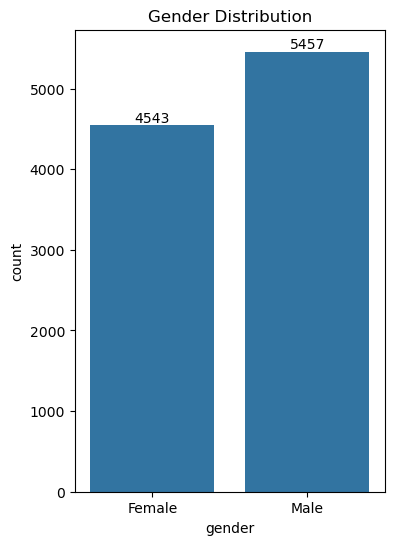

In [318]:
plt.figure(figsize =(4,6))
ax = sns.countplot(data = df, x = "gender")
ax.bar_label(ax.containers[0])
plt.title("Gender Distribution")
plt.show()

In [235]:
# from the chart we can see number of female is less than of male.

In [292]:
gb = df.groupby("tenure").agg({"products_number":'mean', "credit_card":'mean', "active_member": 'mean', "churn":'mean'})
print(gb)

        products_number  credit_card  active_member     churn
tenure                                                       
0              1.443099     0.648910       0.530266  0.230024
1              1.489855     0.677295       0.549758  0.224155
2              1.589695     0.704198       0.534351  0.191794
3              1.533201     0.723489       0.519326  0.211100
4              1.516684     0.716886       0.505561  0.205258
5              1.554348     0.691700       0.500000  0.206522
6              1.519131     0.717684       0.516029  0.202689
7              1.530156     0.706226       0.520428  0.172179
8              1.522927     0.723902       0.506341  0.192195
9              1.535569     0.703252       0.478659  0.216463
10             1.559184     0.724490       0.508163  0.206122


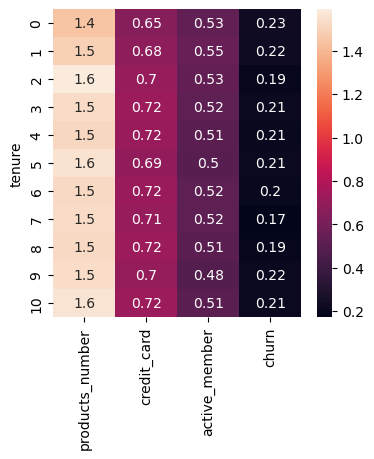

In [300]:
plt.figure(figsize =(4,4))
sns.heatmap(gb, annot = True)
plt.show()

In [306]:
gb1 = df.groupby("country").agg({"age": 'mean', "credit_card":'mean', "active_member": 'mean', "churn":'mean'})
print(gb1)

               age  credit_card  active_member     churn
country                                                 
France   38.511767     0.706621       0.516753  0.161548
Germany  39.771622     0.713830       0.497409  0.324432
Spain    38.890997     0.694792       0.529673  0.166734


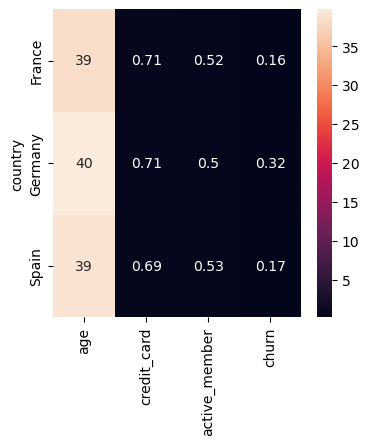

In [314]:
plt.figure(figsize= (4,4))
sns.heatmap(gb1, annot =True)
plt.show()

<Axes: xlabel='estimated_salary'>

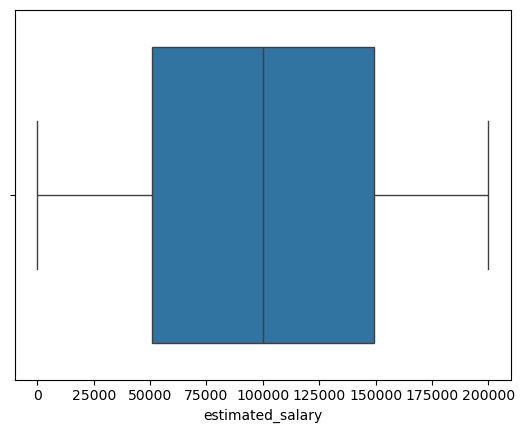

In [322]:
sns.boxplot(data = df, x ="estimated_salary")

In [334]:
print(df["country"].unique())

['France' 'Spain' 'Germany']


#Distrubution of country

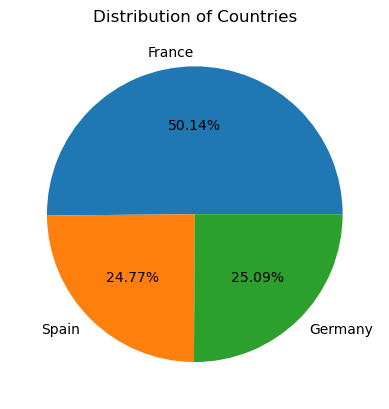

In [365]:
groupA = df.loc[(df['country'] =="France")].count()
groupB = df.loc[(df['country'] =="Spain")].count()
groupC = df.loc[(df['country'] =="Germany")].count()
#print(groupA["country"])
l = ["France", "Spain", "Germany"]
mlist = [groupA["country"], groupB["country"], groupC["country"]]
plt.pie(mlist, labels = l, autopct = "%1.2f%%")
plt.title("Distribution of Countries")
plt.show()

[Text(0, 0, '4543'), Text(0, 0, '5457')]

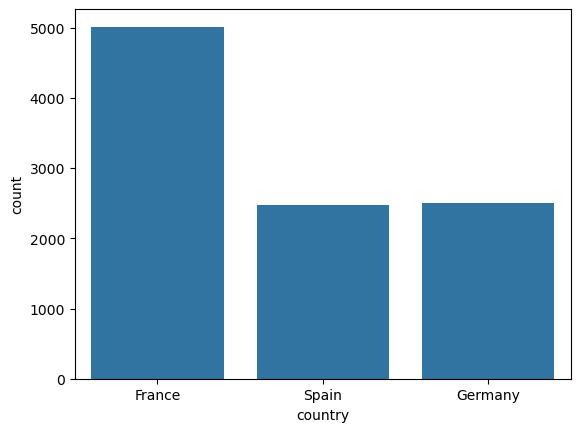

In [367]:
sns.countplot(data = df, x = 'country')
ax.bar_label(ax.containers[0])